# Анализ IT-вакансий HeadHunter

## 1. Постановка задачи

### Предметная область
Рынок труда IT-специалистов в России по данным публичного API HeadHunter.

### Бизнес-контекст

Работодатели часто назначают зарплату субъективно, без точной привязки к рынку, а соискатели не всегда знают справедливый диапазон для своих навыков. Это замедляет наём и снижает прозрачность рынка. Автоматическая оценка на основе реальных вакансий позволяет формировать конкурентное предложение, опираясь на данные, а не на интуицию.

### Задача
Построить ML-модель, предсказывающую уровень зарплаты IT-вакансии по её характеристикам: опыт, город, роль, занятость, график, ключевые навыки и текстовое описание. Проект демонстрирует полный ML-пайплайн: от EDA и обработки текстов (TF-IDF) до подбора гиперпараметров (RandomizedSearchCV), кросс-валидации и интерпретации Permutation Importance. 


## 2. Описание данных
Датасет [IT Vacancies from HeadHunter](https://www.kaggle.com/datasets/ilyazawilsiv/it-vacancies-from-headhunter-website) - вакансии, собранные через публичное API HeadHunter по всей России за месяц (18.09–17.10.2023).  
Объём: ~68,000 записей х 54 признака.

#### Описание признаков
| Признак | Тип | Описание |
|---|---|---|
| salary_from | Числовой (целевой) | Нижняя граница зарплаты, руб. |
| experience | Категориальный | Требуемый опыт (1-3 года, 3-6 лет и др.) |
| area_name | Категориальный | Город вакансии |
| professional_roles_name | Категориальный | Профессия/роль |
| key_skills | Текстовый | Перечень ключевых навыков |
| description | Текстовый | Полное описание (с HTML-тегами) |
| schedule | Категориальный | График работы |
| employment | Категориальный | Тип занятости |

И другие. Подробнее - в этапе отбора признаков.

#### Особенности
- Целевая переменная указана лишь в ~39% вакансий - строки без зарплаты будут исключены.
- Сильная правосторонняя асимметрия целевой переменной: от 10 руб. до 40 млн руб. - выбросы будут ограничены.
- Текстовые поля требуют отдельной обработки (TF-IDF, стоп-слова).
- Дисбаланс по регионам - ~41% вакансий приходится на Москву.
- Данные за один месяц - не отражают сезонные колебания и долгосрочные тренды.


## 3. Предварительный анализ данных (EDA)

- Размер данных, типы признаков
- Доля пропусков, дубликатов и выбросов
- Распределение зарплат: гистограмма и boxplot с ограничением выбросов
- Распределение опыта, города и роли
- Зависимость зарплаты от опыта, города и профессиональной роли


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import seaborn as sns
import lightgbm as lgb
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import RandomizedSearchCV, cross_val_score, cross_validate
from sklearn.utils import resample

In [4]:
df = pd.read_csv('it_vacancies.csv')

print("Размер данных:", df.shape)
print("\nПервые 5 строк:")
df.head()

Размер данных: (68770, 54)

Первые 5 строк:


,id,area_id,area_name,name,test_required,salary_to,salary_from,salary_gross,salary_currency,address_lat,...,accept_temporary,accept_handicapped,professional_roles_id,professional_roles_name,working_time_modes,driver_license_types,working_time_intervals,quick_responses_allowed,response_letter_required,accept_incomplete_resumes
0,85146733,2,Санкт-Петербург,Тестировщик / QA Engineer (Junior / Middle / S...,NaN,NaN,NaN,NaN,NaN,59.984924,...,False,True,124,Тестировщик,NaN,NaN,NaN,False,False,False
1,87391606,1,Москва,Ведущий Системный Аналитик Kleiber.Graphics,NaN,250000.0,230000.0,False,RUR,NaN,...,False,False,148,Системный аналитик,NaN,NaN,NaN,False,False,False
2,85896506,79,Саратов,Бизнес-аналитик,NaN,NaN,NaN,NaN,NaN,NaN,...,False,False,10,Аналитик,NaN,NaN,NaN,False,False,False
3,86876446,72,Пермь,Менеджер проектов/Аккаунт-менеджер (IT сфера) ...,NaN,NaN,NaN,NaN,NaN,58.004460,...,False,False,107,Руководитель проектов,NaN,NaN,NaN,False,False,False
4,84560508,76,Ростов-на-Дону,"Специалист службы поддержки (удаленно), Ростов...",NaN,NaN,35000.0,True,RUR,NaN,...,False,False,121,Специалист технической поддержки,NaN,NaN,NaN,False,False,False


In [5]:
print(f"\nНазвания столбцов: {df.columns.tolist()}")
print(f"\nТипы данных:")
print(df.dtypes)


Названия столбцов: ['id', 'area_id', 'area_name', 'name', 'test_required', 'salary_to', 'salary_from', 'salary_gross', 'salary_currency', 'address_lat', 'address_lng', 'address_raw', 'address_city', 'metro_line_id', 'metro_line_name', 'metro_station_name', 'metro_lat', 'metro_lng', 'address_street', 'address_building', 'count_metro_stations', 'metro_stations', 'premium', 'archived', 'employer_id', 'employer_name', 'employer_trusted', 'accredited_it_employer', 'has_test', 'schedule', 'languages', 'created_at', 'published_at', 'initial_created_at', 'department', 'employment', 'experience', 'key_skills', 'count_key_skills', 'accept_kids', 'description', 'billing_type', 'working_days', 'allow_messages', 'accept_temporary', 'accept_handicapped', 'professional_roles_id', 'professional_roles_name', 'working_time_modes', 'driver_license_types', 'working_time_intervals', 'quick_responses_allowed', 'response_letter_required', 'accept_incomplete_resumes']

Типы данных:
id                        

In [6]:
print("Пропуски по столбцам:")
missing = df.isnull().sum()
missing_pct = missing / len(df) * 100
missing_df = pd.DataFrame({'пропусков': missing, '%': missing_pct})
print(missing_df[missing_df['пропусков'] > 0].sort_values('пропусков', ascending=False))

Пропуски по столбцам:
                        пропусков          %
driver_license_types        68666  99.848771
working_days                68457  99.544860
working_time_modes          67935  98.785808
working_time_intervals      67106  97.580340
test_required               66854  97.213901
languages                   64136  93.261597
department                  60815  88.432456
metro_lng                   52097  75.755417
metro_line_id               52097  75.755417
metro_line_name             52097  75.755417
metro_station_name          52097  75.755417
metro_lat                   52097  75.755417
metro_stations              52097  75.755417
salary_to                   51222  74.483059
salary_from                 41988  61.055693
salary_gross                38366  55.788861
salary_currency             38360  55.780137
address_building            36123  52.527265
address_street              35086  51.019340
address_city                34177  49.697543
address_lat                 33917

In [7]:
print(f"Количество полных дубликатов строк: {df.duplicated().sum()}")
print(f"Дубликатов по id: {df['id'].duplicated().sum() if 'id' in df.columns else 'нет'}")

Количество полных дубликатов строк: 0
Дубликатов по id: 0


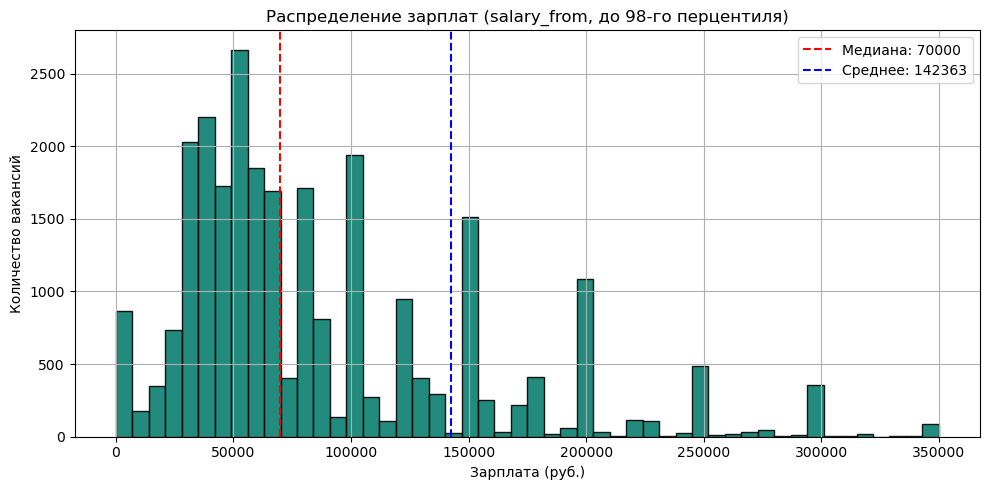

In [84]:
fig, ax = plt.subplots(figsize=(10, 5))
salary_clean = df['salary_from'].dropna()
cap = salary_clean.quantile(0.98)
salary_clean[salary_clean <= cap].hist(bins=50, ax=ax, edgecolor='black', alpha=0.9, color='#0A7E6F')
ax.axvline(salary_clean.median(), color='red', linestyle='--', label=f'Медиана: {salary_clean.median():.0f}')
ax.axvline(salary_clean.mean(), color='blue', linestyle='--', label=f'Среднее: {salary_clean.mean():.0f}')
ax.set_title('Распределение зарплат (salary_from, до 98-го перцентиля)')
ax.set_xlabel('Зарплата (руб.)')
ax.set_ylabel('Количество вакансий')
ax.legend()
plt.tight_layout()
plt.show()

In [155]:
salary_stats = df['salary_from'].describe()
print("Статистика salary_from (руб.):")
print(f"Количество непустых: {salary_stats['count']:.0f}")
print(f"Среднее: {salary_stats['mean']:.0f}")
print(f"Станд. отклонение: {salary_stats['std']:.0f}")
print(f"Минимум: {salary_stats['min']:.0f}")
print(f"25-й перцентиль: {salary_stats['25%']:.0f}")
print(f"Медиана: {salary_stats['50%']:.0f}")
print(f"75-й перцентиль: {salary_stats['75%']:.0f}")
print(f"99-й перцентиль: {df['salary_from'].quantile(0.99):.0f}")
print(f"Максимум: {salary_stats['max']:.0f}")
print(f"\nДоля вакансий с указанной зарплатой: {salary_stats['count']/len(df)*100:.1f}%")

Статистика salary_from (руб.):
Количество непустых: 26782
Среднее: 142363
Станд. отклонение: 830726
Минимум: 10
25-й перцентиль: 43000
Медиана: 70000
75-й перцентиль: 120000
99-й перцентиль: 600000
Максимум: 40000000

Доля вакансий с указанной зарплатой: 38.9%


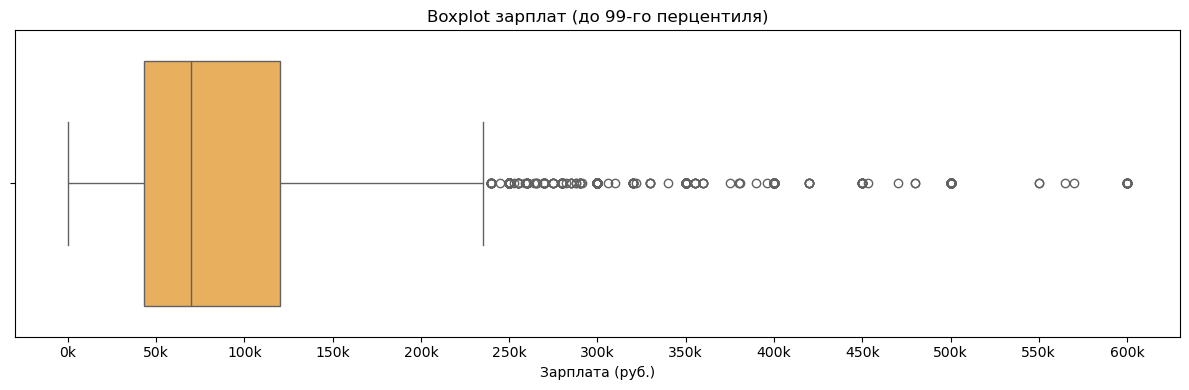

In [68]:
fig, ax = plt.subplots(figsize=(12, 4))
salary_capped = df['salary_from'].dropna()
salary_capped = salary_capped[salary_capped <= salary_capped.quantile(0.99)]
sns.boxplot(x=salary_capped, ax=ax, color='#FFB347')
ax.set_title('Boxplot зарплат (до 99-го перцентиля)', fontsize=12)
ax.set_xlabel('Зарплата (руб.)')
ax.tick_params(axis='x', rotation=0)

ax.xaxis.set_major_locator(MultipleLocator(50000))  # деления каждые 50 000 руб.
ax.xaxis.set_major_formatter(lambda x, p: f'{int(x/1000)}k' if x < 1000000 else f'{int(x/1000000)}M')

plt.tight_layout()
plt.show()

### Вывод по зарплатам

Средняя зарплата - 142k руб., медиана - 70k руб. Разрыв указывает на правостороннюю асимметрию: основная масса вакансий сосредоточена в диапазоне 45-120k, а высокие зарплаты (от 240k) соответствуют топ-менеджерам и senior-позициям. Единичные аномалии (10 руб., 40 млн руб.) будут исключены: нижний порог - 15k, верхний - 99-й перцентиль (~500k). Зарплата указана в 39% вакансий - строки без неё удалены.


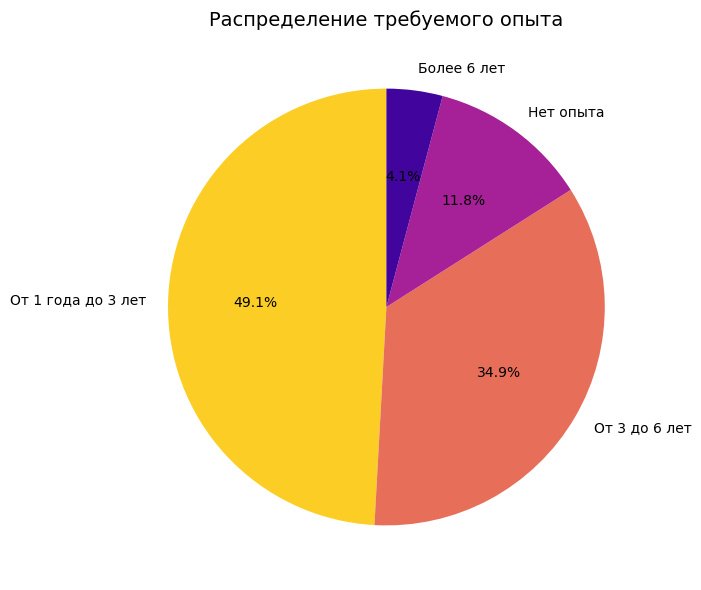

In [98]:
# print("Распределение опыта:")
# print(df_clean['experience'].value_counts())

fig, ax = plt.subplots(figsize=(8, 6))
experience_counts = df['experience'].value_counts()
colors = ['#27AE60', '#FF8C42', '#FFF000', '#6A4C93'] 
colors = ['#66c2a5', '#fc8d62', '#8da0cb', '#e78ac3']
colors = plt.cm.plasma(np.linspace(0.9, 0.1, len(experience_counts)))
wedges, texts, autotexts = ax.pie(experience_counts, labels=experience_counts.index, 
                                    autopct='%1.1f%%', startangle=90, colors=colors)
ax.set_title('Распределение требуемого опыта', fontsize=14)
plt.tight_layout()
plt.show()

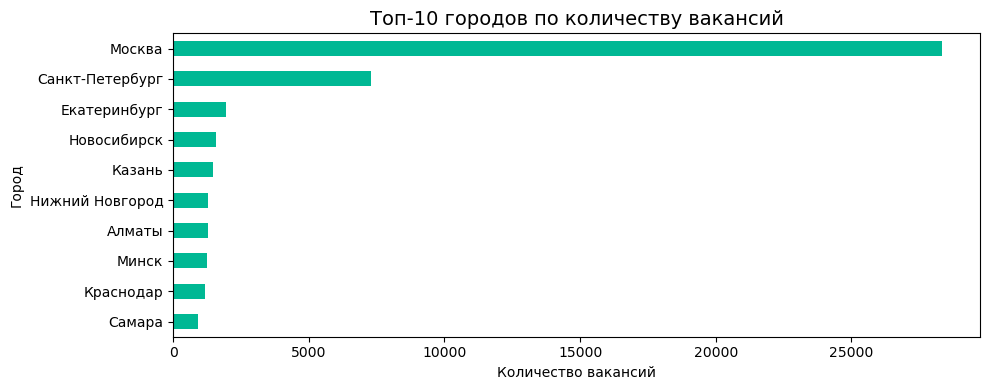

In [47]:
# print("Распределение по городам (топ-10):")
# print(df_clean['area_name'].value_counts().head(10))

fig, ax = plt.subplots(figsize=(10, 4))
city_counts = df['area_name'].value_counts().head(10)
city_counts.sort_values().plot(kind='barh', ax=ax, color='#00B894')
ax.set_title('Топ-10 городов по количеству вакансий', fontsize=14)
ax.set_xlabel('Количество вакансий')
ax.set_ylabel('Город')
plt.tight_layout()
plt.show()

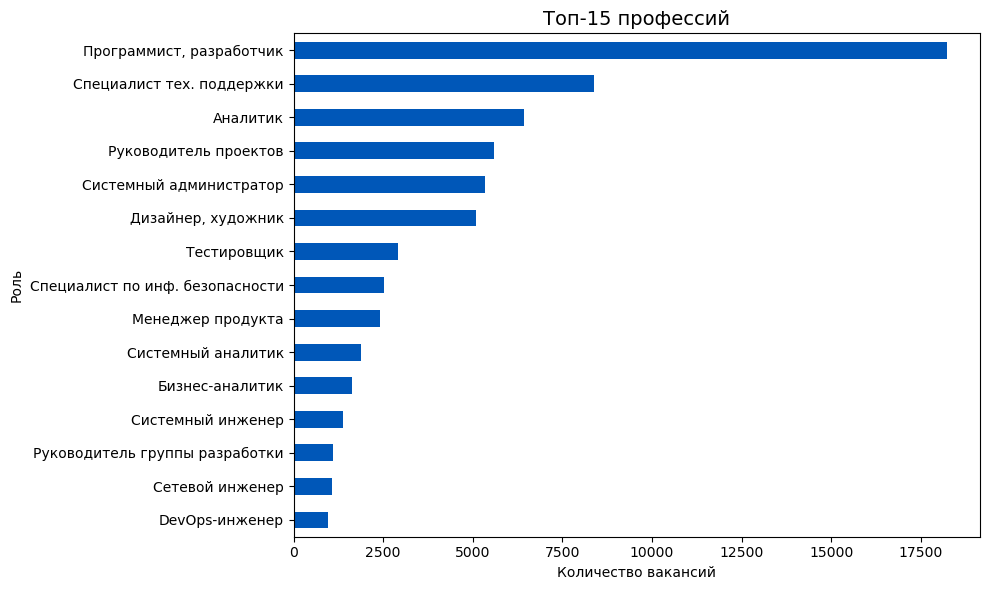

In [19]:
def shorten_role(name): # Функция для сокращения длинных названий ролей
    if 'Специалист технической поддержки' in name:
        return 'Специалист тех. поддержки'
    elif 'Специалист по информационной безопасности' in name:
        return 'Специалист по инф. безопасности'
    else:
        return name

df['role_short'] = df['professional_roles_name'].apply(shorten_role)

fig, ax = plt.subplots(figsize=(10, 6))
role_counts = df['role_short'].value_counts().head(15)
role_counts.sort_values().plot(kind='barh', ax=ax, color='#0057B8')
ax.set_title('Топ-15 профессий', fontsize=14)
ax.set_xlabel('Количество вакансий')
ax.set_ylabel('Роль')
plt.tight_layout()
plt.show()

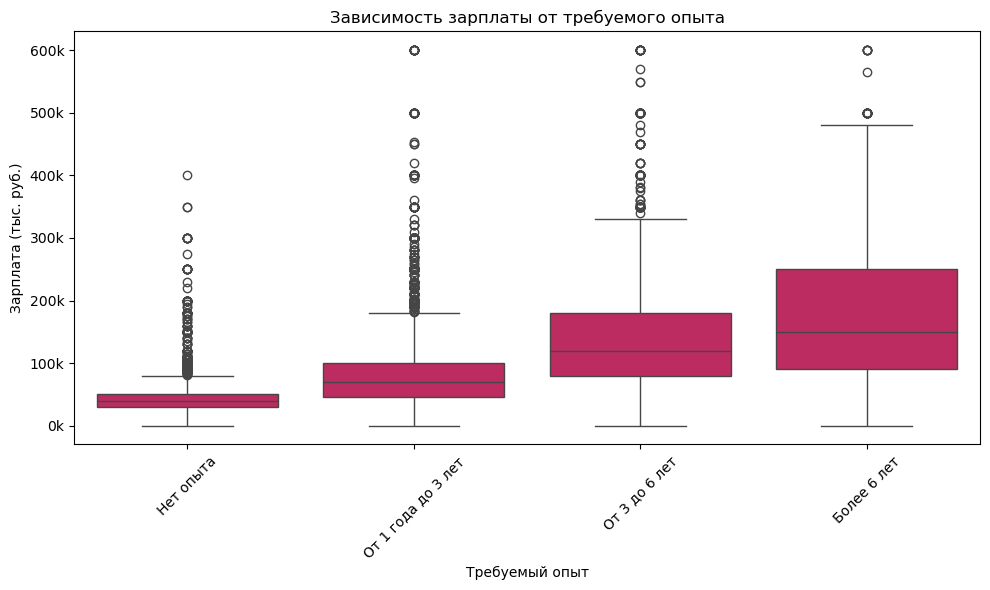

In [85]:
fig, ax = plt.subplots(figsize=(10, 6))

data_for_plot = df[['experience', 'salary_from']].dropna()
salary_cap = data_for_plot['salary_from'].quantile(0.99)
data_for_plot = data_for_plot[data_for_plot['salary_from'] <= salary_cap]

order = ['Нет опыта', 'От 1 года до 3 лет', 'От 3 до 6 лет', 'Более 6 лет']
sns.boxplot(data=data_for_plot, x='experience', y='salary_from', order=order, ax=ax, color='#d4145a')

ax.set_title('Зависимость зарплаты от требуемого опыта', fontsize=12)
ax.set_xlabel('Требуемый опыт')
ax.set_ylabel('Зарплата (тыс. руб.)')
ax.tick_params(axis='x', rotation=45)

def y_fmt(x, p):
    return f'{int(x/1000)}k' if x < 1000000 else f'{int(x/1000000)}млн'

ax.yaxis.set_major_formatter(plt.FuncFormatter(y_fmt))

plt.tight_layout()
plt.show()

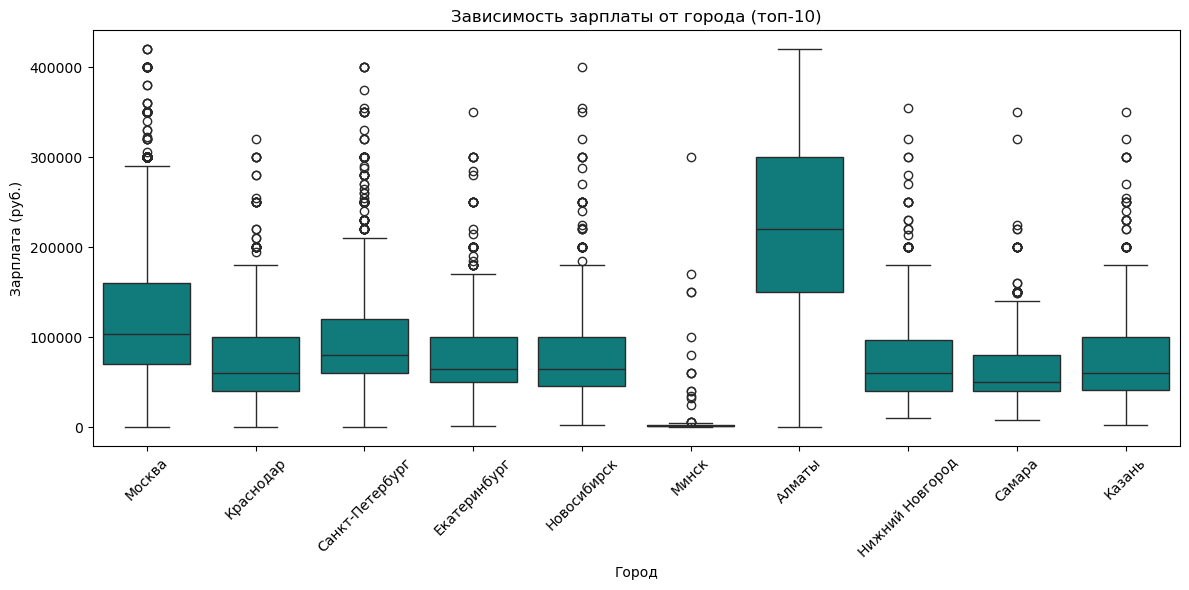

In [14]:
fig, ax = plt.subplots(figsize=(12, 6))
top_cities = df['area_name'].value_counts().head(10).index
city_salary = df[df['area_name'].isin(top_cities)][['area_name', 'salary_from']].dropna()
salary_cap = city_salary['salary_from'].quantile(0.99)
city_salary = city_salary[city_salary['salary_from'] <= salary_cap]
sns.boxplot(data=city_salary, x='area_name', y='salary_from', ax=ax, color='#008B8B')
ax.set_title('Зависимость зарплаты от города (топ-10)')
ax.set_xlabel('Город')
ax.set_ylabel('Зарплата (руб.)')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
# plt.savefig('salary_by_city.png', dpi=300, bbox_inches='tight')
plt.show()

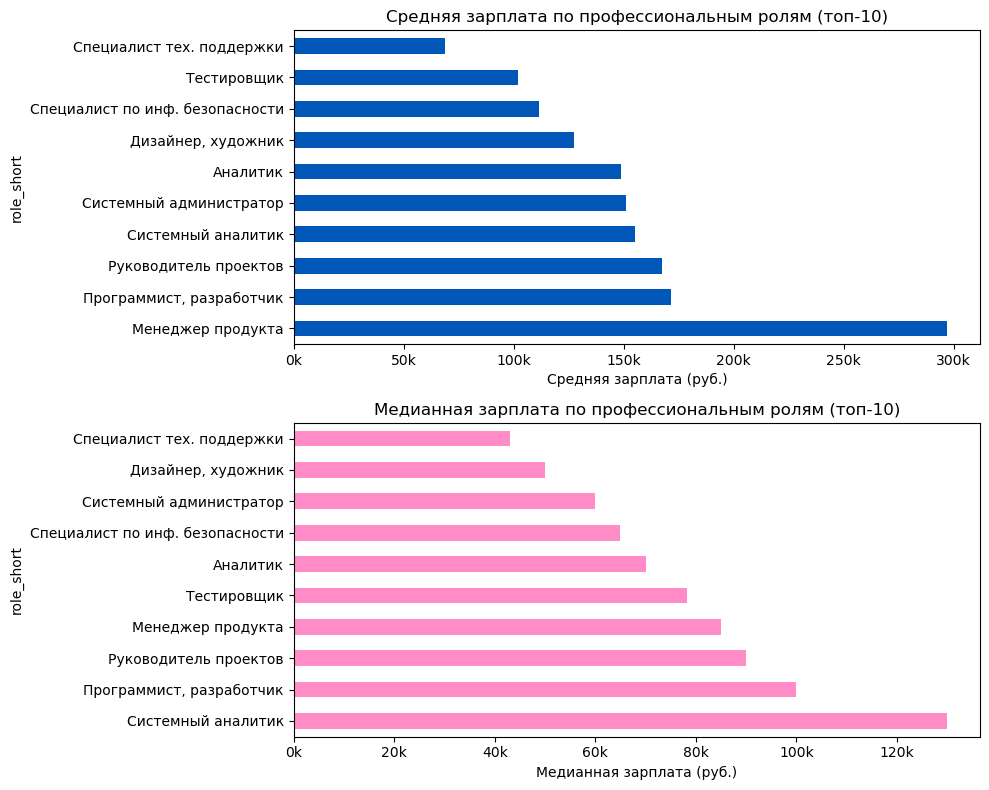

In [20]:
fig, axes = plt.subplots(2, 1, figsize=(10, 8))
top_roles = df['role_short'].value_counts().head(10).index

role_salary_mean = df[df['role_short'].isin(top_roles)].groupby('role_short')['salary_from'].mean().sort_values(ascending=False).round(0)
role_salary_mean.plot(kind='barh', ax=axes[0], color='#0057B8')
axes[0].set_title('Средняя зарплата по профессиональным ролям (топ-10)', fontsize=12)
axes[0].set_xlabel('Средняя зарплата (руб.)')

role_salary_median = df[df['role_short'].isin(top_roles)].groupby('role_short')['salary_from'].median().sort_values(ascending=False).round(0)
role_salary_median.plot(kind='barh', ax=axes[1], color='#FF8CC6')
axes[1].set_title('Медианная зарплата по профессиональным ролям (топ-10)', fontsize=12)
axes[1].set_xlabel('Медианная зарплата (руб.)')

def x_fmt(x, p):
    return f'{int(x/1000)}k' if x < 1000000 else f'{int(x/1000000)}млн'

for ax in axes:
    ax.xaxis.set_major_formatter(plt.FuncFormatter(x_fmt))

plt.tight_layout()
# plt.savefig('avg_salary_by_role.png', dpi=300, bbox_inches='tight')
plt.show()

## 4. Подготовка данных
Выполнено:
- Удалены строки без зарплаты, заполнены пропуски
- Исключены выбросы: зарплата ограничена [15k, 99-й перцентиль]
- 5 категориальных признаков закодированы LabelEncoder
- 2 текстовых признака векторизованы TF-IDF (100 + 200 фич)
- Все признаки объединены → StandardScaler → train/test (80/20)

### Отбор признаков
Из 54 исходных колонок отобраны 8 информативных: `experience`, `area_name`, `professional_roles_name`, `schedule`, `employment`, `key_skills`, `description`, `salary_from` (целевая).  

Исключены столбцы:
- **Технические и дублирующие:** id, employer_id, professional_roles_id, billing_type, флаги отклика, published_at/created_at
- **Геоданные высокой кардинальности:** адреса, координаты, метро (~10 признаков — дублируют area_name или избыточно детальны)
- **Социальные/медицинские флаги:** не влияют на зарплату (6 признаков)
- **Признаки с >88% пропусков:** working_days, languages, department и др. (6 признаков)
- **Неинформативные/субъективные:** premium (премиум-вакансия), employer_trusted (доверенный работодатель), archived (архивность вакансии).


In [5]:
features = [
    'salary_from',               
    'area_name',                  
    'experience',                 
    'professional_roles_name',   
    'schedule',                   
    'employment',                                 
    'key_skills',                 
    'description'                 
]

df_ml = df[features]
print(f"Размер данных: {df_ml.shape}")
print("\nПервые 5 строк:")
df_ml.head(5)

Размер данных: (68770, 8)

Первые 5 строк:


,salary_from,area_name,experience,professional_roles_name,schedule,employment,key_skills,description
0,NaN,Санкт-Петербург,От 1 года до 3 лет,Тестировщик,Полный день,Полная занятость,"{Тестирование,QA,""Selenium IDE"",Python}","<p>В команду Typescript, Javascript разработки..."
1,230000.0,Москва,От 3 до 6 лет,Системный аналитик,Удаленная работа,Полная занятость,"{BPMN,UML,""Agile Project Management"",""Системны...",<p><em><strong>Привет!</strong></em></p> <p><e...
2,NaN,Саратов,От 3 до 6 лет,Аналитик,Полный день,Полная занятость,"{BPMN,UML,Бизнес-анализ,""Деловая коммуникация""...",<p><strong>Компания РайтКод ищет специалиста н...
3,NaN,Пермь,От 1 года до 3 лет,Руководитель проектов,Полный день,Полная занятость,"{""Управление проектами"",""Ведение переговоров"",...",<p>Солар групп - самый крупный веб-интегратор ...
4,35000.0,Ростов-на-Дону,Нет опыта,Специалист технической поддержки,Удаленная работа,Полная занятость,NaN,<p><strong>Чем предстоит заниматься</strong></...


### Обработка пропусков
Строки без зарплаты удалены, т.к. это целевая переменная. Пропуски в key_skills заполнены пустой строкой.

### Обработка выбросов в целевой переменной
Зарплата ограничена снизу 15k руб. (исключены нереалистично низкие значения) и сверху 99-м перцентилем для устранения аномалий.

### Разделение на признаки и целевую переменную
Целевая переменная salary_from выделена в отдельный массив y. Остальные столбцы образуют матрицу признаков X для обучения модели регрессии.

In [6]:
print("Пропуски до обработки:")
missing = df_ml.isnull().sum()
missing_pct = (missing / len(df_ml)) * 100
missing_df = pd.DataFrame({'пропусков': missing, '%': missing_pct})
print(missing_df[missing_df['пропусков'] > 0])

df_ml = df_ml.dropna(subset=['salary_from']) # строки без з/п
df_ml['key_skills'] = df_ml['key_skills'].fillna('') # пропуски

print("\nПропуски после обработки:")
print(df_ml[['salary_from', 'key_skills']].isnull().sum())

df_ml = df_ml[df_ml['salary_from'] >= 15000] # строки с з/п ниже 15k руб.
cap = df_ml['salary_from'].quantile(0.99) # 99 перцентиль
df_ml = df_ml[df_ml['salary_from'] <= cap]

y = df_ml['salary_from']
X = df_ml.drop('salary_from', axis=1)
print(f"\nМатрица признаков X: {X.shape}")

Пропуски до обработки:
             пропусков          %
salary_from      41988  61.055693
key_skills       22984  33.421550

Пропуски после обработки:
salary_from    0
key_skills     0
dtype: int64

Матрица признаков X: (25495, 7)


### Кодирование категориальных признаков
Категориальные признаки преобразованы через `LabelEncoder` — каждому уникальному значению (город, опыт, роль, график, занятость) присвоен целочисленный код.


In [7]:
cat_cols = ['area_name', 'experience', 'professional_roles_name', 'schedule', 'employment']
cat_cols_present = [col for col in cat_cols if col in X.columns]
for col in cat_cols_present:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    print(f"{col}: {len(le.classes_)} уникальных значений")

area_name: 852 уникальных значений
experience: 4 уникальных значений
professional_roles_name: 25 уникальных значений
schedule: 5 уникальных значений
employment: 4 уникальных значений


### Векторизация текстовых признаков

Текстовые признаки `key_skills` и `description` преобразованы через TF-IDF (100 и 200 признаков соответственно). TF-IDF оценивает слова по их важности внутри вакансии относительно всего корпуса - значимые термины (Python, SQL, «руководитель») получают больший вес.  
Итоговая матрица содержит: 
- 5 категориальных признаков
- 100 текстовых признаков из key_skills
- 200 текстовых признаков из description


In [8]:
tfidf_skills = TfidfVectorizer(max_features=100)
X_skills = tfidf_skills.fit_transform(X['key_skills'])

tfidf_desc = TfidfVectorizer(max_features=200)
X_desc = tfidf_desc.fit_transform(X['description'])

X = X.drop(['key_skills', 'description'], axis=1)
print(f"Признаков от key_skills: {X_skills.shape[1]}, от description: {X_desc.shape[1]}")

Признаков от key_skills: 100, от description: 200


In [9]:
X_all = hstack([X.values, X_skills, X_desc]) # объединение всех признаков
print(f"Итоговая матрица признаков: {X_all.shape}")

Итоговая матрица признаков: (25495, 305)


### Масштабирование
Для масштабирования признаков использован StandardScaler с параметром with_mean=False (из-за разреженности матрицы).

### Разбиение на обучающую и тестовую выборки
Данные разделены 80/20 с random_state=42 для воспроизводимости.

In [10]:
scaler = StandardScaler(with_mean=False) 
X_scaled = scaler.fit_transform(X_all)

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print(f"Обучающая выборка: {X_train.shape[0]} записей")
print(f"Тестовая выборка: {X_test.shape[0]} записей")

Обучающая выборка: 20396 записей
Тестовая выборка: 5099 записей


## 5. Построение baseline
В качестве baseline выбран `DummyRegressor` (стратегия "median") - модель всегда предсказывает медианную зарплату (~70k руб.), игнорируя входные признаки. Используется как нижняя граница качества: любая содержательная модель должна её превзойти.

Метрики:
- MAE - на сколько рублей в среднем предсказание отклоняется от реальной зарплаты.
- RMSE - сильнее штрафует крупные промахи.
- R² - доля объяснённой дисперсии (для DummyRegressor близок к нулю или отрицателен).


Baseline: DummyRegressor (медиана)

Обучающая выборка:
MAE: 48836 руб.
RMSE: 77052 руб.
R²: -0.1149

Тестовая выборка:
MAE: 48658 руб.
RMSE: 76175 руб.
R²: -0.1089

Медианная зарплата в обучающей выборке: 70000 руб.



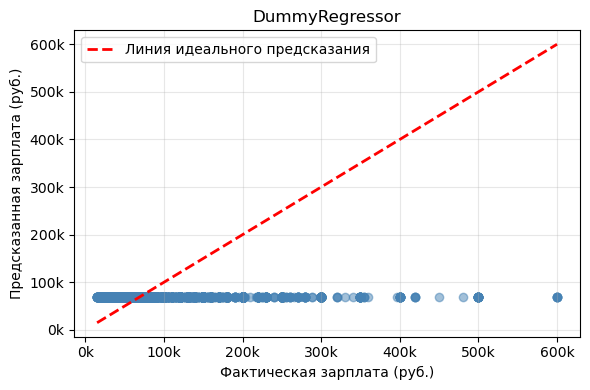

In [14]:
dummy = DummyRegressor(strategy='median')
dummy.fit(X_train, y_train)

y_train_pred_dummy = dummy.predict(X_train)
y_test_pred_dummy = dummy.predict(X_test)

print("Baseline: DummyRegressor (медиана)")

print("\nОбучающая выборка:")
print(f"MAE: {mean_absolute_error(y_train, y_train_pred_dummy):.0f} руб.")
print(f"RMSE: {np.sqrt(mean_squared_error(y_train, y_train_pred_dummy)):.0f} руб.")
print(f"R²: {r2_score(y_train, y_train_pred_dummy):.4f}")
print("\nТестовая выборка:")
print(f"MAE: {mean_absolute_error(y_test, y_test_pred_dummy):.0f} руб.")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_test_pred_dummy)):.0f} руб.")
print(f"R²: {r2_score(y_test, y_test_pred_dummy):.4f}")

print(f"\nМедианная зарплата в обучающей выборке: {np.median(y_train):.0f} руб.\n")

fig, ax = plt.subplots(figsize=(6, 4))

ax.scatter(y_test, y_test_pred_dummy, alpha=0.5, color='steelblue')
ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Линия идеального предсказания')
ax.set_xlabel('Фактическая зарплата (руб.)')
ax.set_ylabel('Предсказанная зарплата (руб.)')
ax.set_title('Предсказания DummyRegressor')
ax.legend()
ax.grid(True, alpha=0.3)

def fmt(x, p):
    return f'{int(x/1000)}k'
ax.xaxis.set_major_formatter(plt.FuncFormatter(fmt))
ax.yaxis.set_major_formatter(plt.FuncFormatter(fmt))

plt.tight_layout()
plt.show()

## 6. Обучение модели
Первая содержательная модель - `RandomForestRegressor` (100 деревьев). Выбран за устойчивость к переобучению, способность улавливать нелинейные зависимости и встроенную оценку важности признаков.

Модель можно сохранить в `.pkl` для повторного использования.

In [15]:
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

y_train_pred_rf = rf.predict(X_train)
y_test_pred_rf = rf.predict(X_test)

print("Random Forest Regressor:")
print(f"MAE train: {mean_absolute_error(y_train, y_train_pred_rf):.0f} руб.")
print(f"MAE test: {mean_absolute_error(y_test, y_test_pred_rf):.0f} руб.")
print(f"R² train: {r2_score(y_train, y_train_pred_rf):.4f}")
print(f"R² test: {r2_score(y_test, y_test_pred_rf):.4f}")

joblib.dump(rf, 'random_forest_model.pkl')
print("\nМодель сохранена как 'random_forest_model.pkl'")

Random Forest Regressor:
MAE train: 10323 руб.
MAE test: 27102 руб.
R² train: 0.9467
R² test: 0.6460

Модель сохранена как 'random_forest_model.pkl'


## 7. Отбор признаков

Значимость признаков оценена через Permutation Importance на обученном Random Forest: каждый признак случайно перемешивается, и измеряется падение качества (MAE). Чем сильнее ухудшение — тем важнее признак.

Также выведена встроенная важность Random Forest (`feature_importances_`) для сравнения.

In [67]:
X_test_sample, y_test_sample = resample(
    X_test, y_test, 
    n_samples=min(5000, X_test.shape[0]), # выборка 5000 строк для экономии времени и памяти
    random_state=42
)

# Преобразует разреженную матрицу в плотный массив
X_test_dense = X_test_sample.toarray() if hasattr(X_test_sample, 'toarray') else X_test_sample

# Вычисляет важность признаков
perm_importance = permutation_importance(rf, X_test_dense, y_test_sample, n_repeats=5, random_state=42, n_jobs=-1)

n_cat = 5  # кол-во категориальных признаков
n_skills = 100
n_desc = 200

feature_names = [f'cat_{i}' for i in range(n_cat)] + [f'skill_{i}' for i in range(n_skills)] + [f'desc_{i}' for i in range(n_desc)]

importance_df = pd.DataFrame({
    'feature': feature_names[:len(perm_importance.importances_mean)],
    'importance': perm_importance.importances_mean,
    'std': perm_importance.importances_std
}).sort_values('importance', ascending=False)


In [68]:
print("Топ-20 важных признаков:")
print(importance_df[['feature', 'importance']].head(20))

Топ-20 важных признаков:
      feature  importance
1       cat_1    0.414927
0       cat_0    0.272528
266  desc_161    0.066000
2       cat_2    0.043792
261  desc_156    0.043087
210  desc_105    0.020248
213  desc_108    0.017349
110    desc_5    0.011936
147   desc_42    0.010425
3       cat_3    0.006229
22   skill_17    0.005956
272  desc_167    0.004940
115   desc_10    0.004500
299  desc_194    0.004455
291  desc_186    0.002516
128   desc_23    0.002501
176   desc_71    0.002377
120   desc_15    0.002320
230  desc_125    0.001885
247  desc_142    0.001707


### Расшифровка признаков

Всего 305 признаков: 5 категориальных (`cat_0`–`cat_4`) и 300 текстовых (`desc_*` — слова из описаний, `skill_*` — ключевые навыки). Ниже — график важности только категориальных признаков с человекочитаемыми названиями.


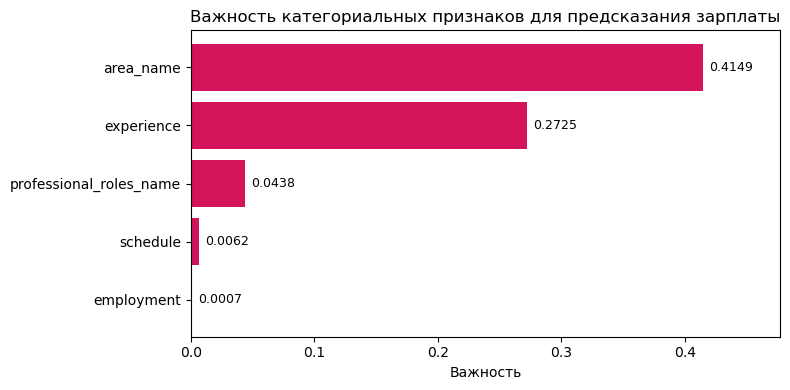

In [69]:
cat_feature_names_with_idx = [
    ('cat_0', 'experience'),
    ('cat_1', 'area_name'),
    ('cat_2', 'professional_roles_name'),
    ('cat_3', 'schedule'),
    ('cat_4', 'employment')
]

cat_importances = [] # важность признаков
cat_labels = []
for cat_idx, label in cat_feature_names_with_idx:
    imp_value = importance_df[importance_df['feature'] == cat_idx]['importance'].values
    if len(imp_value) > 0:
        cat_importances.append(imp_value[0])
    else:
        cat_importances.append(0)
    cat_labels.append(label)

cat_importance_df = pd.DataFrame({
    'feature': cat_labels,
    'importance': cat_importances
}).sort_values('importance', ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(cat_importance_df['feature'], cat_importance_df['importance'], color='#d4145a')
ax.set_xlabel('Важность')
ax.set_title('Важность категориальных признаков для предсказания зарплаты', fontsize=12)
ax.set_xlim(0, cat_importance_df['importance'].max() * 1.15)  # доб. отступ 15%

for bar, val in zip(bars, cat_importance_df['importance']):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2, f'{val:.4f}', va='center', fontsize=9)

ax.invert_yaxis()
plt.tight_layout()
plt.show()

### Вывод по важности (Permutation Importance)

- Город и опыт - ключевые факторы зарплаты
- Роль - средней значимости
- График и занятость влияют слабо

Все 5 категориальных признаков сохранены (важность выше 0). Текстовые TF-IDF признаки также оставлены без дополнительного отсева.

### Встроенная важность Random Forest

Топ-15 во многом совпадает с Permutation Importance. Это подтверждает устойчивость найденных закономерностей к методу оценки.

In [17]:
# Встроенная важность из Random Forest
rf_feature_importance = pd.DataFrame({
    'feature': feature_names[:rf.feature_importances_.shape[0]],
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

print("Топ-15 важных признаков (по Random Forest):")
print(rf_feature_importance.head(15))

Топ-15 важных признаков (по Random Forest):
      feature  importance
1       cat_1    0.220862
0       cat_0    0.167328
261  desc_156    0.040605
213  desc_108    0.020630
147   desc_42    0.016977
2       cat_2    0.016565
266  desc_161    0.015631
115   desc_10    0.011676
110    desc_5    0.011479
120   desc_15    0.009106
254  desc_149    0.008541
3       cat_3    0.008402
188   desc_83    0.008167
299  desc_194    0.007915
121   desc_16    0.007529


## 8. Сравнение моделей

Обучены три модели разного уровня сложности:
- **Linear Regression** - линейный baseline после DummyRegressor, проверяет, насколько данные линейно разделимы.
- **Random Forest** - ансамбль деревьев, устойчив к переобучению.
- **LightGBM** - градиентный бустинг, наиболее сильная модель для табличных данных.

Метрики: MAE и R² на train и test.


In [16]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_train_pred_lr = lr.predict(X_train)
y_test_pred_lr = lr.predict(X_test)

print("Linear Regression:")
print(f"MAE train: {mean_absolute_error(y_train, y_train_pred_lr):.0f} руб.")
print(f"MAE test: {mean_absolute_error(y_test, y_test_pred_lr):.0f} руб.")
print(f"R² train: {r2_score(y_train, y_train_pred_lr):.4f}")
print(f"R² test: {r2_score(y_test, y_test_pred_lr):.4f}")

Linear Regression:
MAE train: 39484 руб.
MAE test: 38965 руб.
R² train: 0.3376
R² test: 0.3401


In [17]:
lgb_model = lgb.LGBMRegressor(n_estimators=100, random_state=42, verbose=-1)
lgb_model.fit(X_train, y_train)

y_train_pred_lgb = lgb_model.predict(X_train)
y_test_pred_lgb = lgb_model.predict(X_test)

print("LightGBM Regressor:")
print(f"MAE train: {mean_absolute_error(y_train, y_train_pred_lgb):.0f} руб.")
print(f"MAE test: {mean_absolute_error(y_test, y_test_pred_lgb):.0f} руб.")
print(f"R² train: {r2_score(y_train, y_train_pred_lgb):.4f}")
print(f"R² test: {r2_score(y_test, y_test_pred_lgb):.4f}")

LightGBM Regressor:
MAE train: 22613 руб.
MAE test: 26333 руб.
R² train: 0.7919
R² test: 0.6779


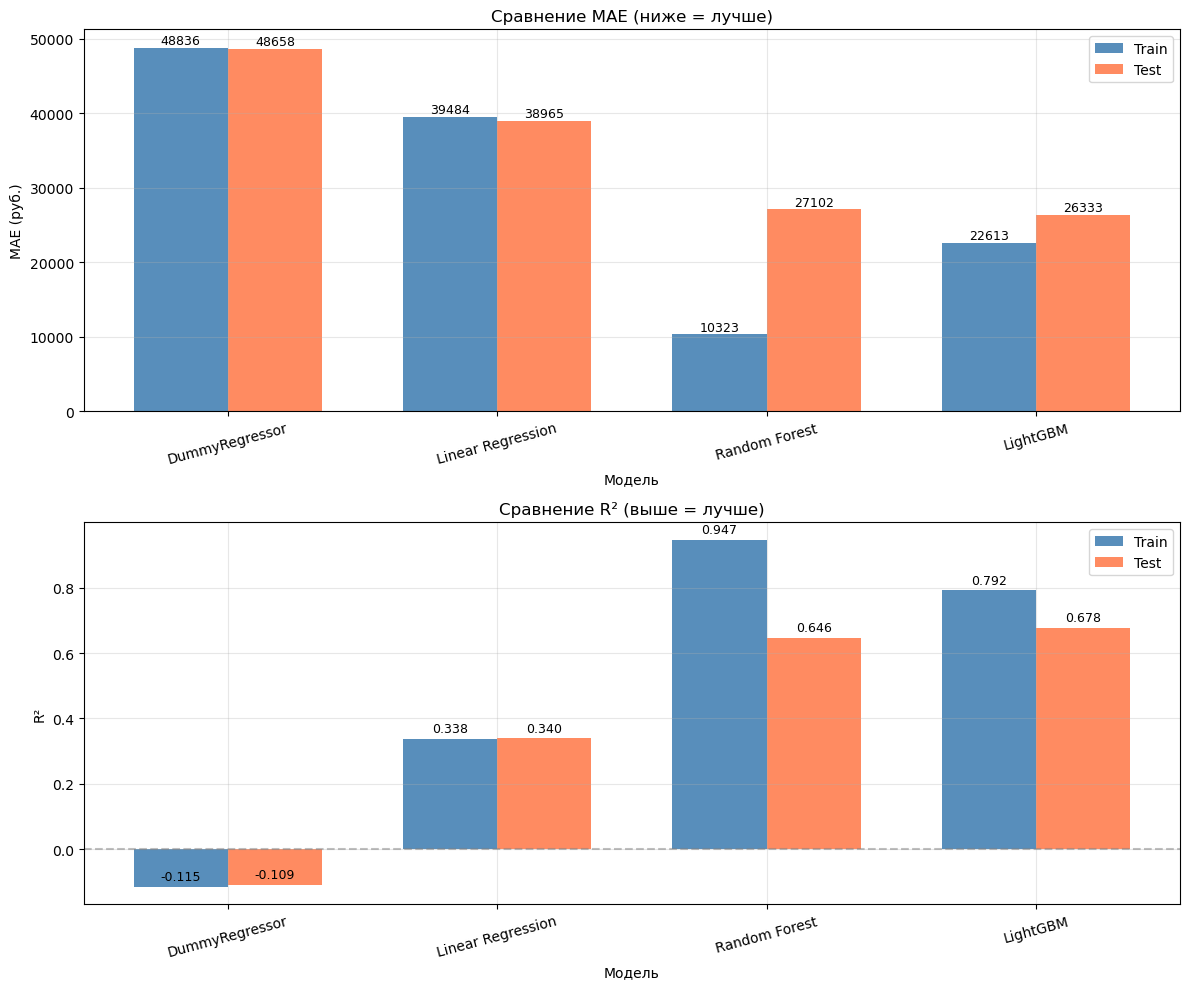

In [187]:
results_models = pd.DataFrame({
    'Model': ['DummyRegressor', 'Linear Regression', 'Random Forest', 'LightGBM'],
    'MAE_train': [
        mean_absolute_error(y_train, y_train_pred_dummy),
        mean_absolute_error(y_train, y_train_pred_lr),
        mean_absolute_error(y_train, y_train_pred_rf),
        mean_absolute_error(y_train, y_train_pred_lgb)
    ],
    'MAE_test': [
        mean_absolute_error(y_test, y_test_pred_dummy),
        mean_absolute_error(y_test, y_test_pred_lr),
        mean_absolute_error(y_test, y_test_pred_rf),
        mean_absolute_error(y_test, y_test_pred_lgb)
    ],
    'R2_train': [
        r2_score(y_train, y_train_pred_dummy),
        r2_score(y_train, y_train_pred_lr),
        r2_score(y_train, y_train_pred_rf),
        r2_score(y_train, y_train_pred_lgb)
    ],
    'R2_test': [
        r2_score(y_test, y_test_pred_dummy),
        r2_score(y_test, y_test_pred_lr),
        r2_score(y_test, y_test_pred_rf),
        r2_score(y_test, y_test_pred_lgb)
    ]
})

# print("Сравнение всех моделей:")
# print(results_models.round(2))

fig, axes = plt.subplots(2, 1, figsize=(12, 10))

models = results_models['Model'].tolist()
x = np.arange(len(models))
width = 0.35

axes[0].bar(x - width/2, results_models['MAE_train'], width, label='Train', color='steelblue', alpha=0.9)
axes[0].bar(x + width/2, results_models['MAE_test'], width, label='Test', color='coral', alpha=0.9)
axes[0].set_xlabel('Модель')
axes[0].set_ylabel('MAE (руб.)')
axes[0].set_title('Сравнение MAE (ниже = лучше)')
axes[0].set_xticks(x)
axes[0].set_xticklabels(models, rotation=15)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

for i, (train_val, test_val) in enumerate(zip(results_models['MAE_train'], results_models['MAE_test'])):
    axes[0].text(i - width/2, train_val + 500, f'{train_val:.0f}', ha='center', fontsize=9)
    axes[0].text(i + width/2, test_val + 500, f'{test_val:.0f}', ha='center', fontsize=9)

axes[1].bar(x - width/2, results_models['R2_train'], width, label='Train', color='steelblue', alpha=0.9)
axes[1].bar(x + width/2, results_models['R2_test'], width, label='Test', color='coral', alpha=0.9)
axes[1].set_xlabel('Модель')
axes[1].set_ylabel('R²')
axes[1].set_title('Сравнение R² (выше = лучше)')
axes[1].set_xticks(x)
axes[1].set_xticklabels(models, rotation=15)
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].axhline(y=0, color='gray', linestyle='--', alpha=0.5)

for i, (train_val, test_val) in enumerate(zip(results_models['R2_train'], results_models['R2_test'])):
    axes[1].text(i - width/2, train_val + 0.02, f'{train_val:.3f}', ha='center', fontsize=9)
    axes[1].text(i + width/2, test_val + 0.02, f'{test_val:.3f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

### Вывод

- Линейная регрессия закономерно обошла DummyRegressor, но уступила ансамблевым методам
- Random Forest демонстрирует сильное переобучение
- LightGBM показал лучший баланс: самый высокий R² на тесте и минимальный разрыв между train и test

Для дальнейшей настройки выбран LightGBM.


## 9. Подбор гиперпараметров LightGBM

Использован `RandomizedSearchCV` (15 итераций, 3-fold CV, метрика R²) вместо полного Grid Search для экономии времени. Диапазоны при подборе - стандартные для табличных данных среднего размера (~20k записей в train).


In [25]:
param_dist = {
    'n_estimators': [100, 200, 300, 500], # кол-во деревьев
    'num_leaves': [15, 31, 63, 127], # максимальное кол-во листьев в дереве
    'learning_rate': [0.01, 0.05, 0.1, 0.2], # скорость градиентного спуска
    'min_child_samples': [5, 10, 20, 50], # минимальное число объектов в листе
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0]
}

lgb_base = lgb.LGBMRegressor(random_state=42, verbose=-1) # созд. базовую модель

random_search = RandomizedSearchCV(
    estimator=lgb_base,
    param_distributions=param_dist,
    n_iter=15,           # кол-во случайных комбинаций
    cv=3,                # 3-кратная кросс-валидация
    scoring='r2',        # метрика для отбора лучших параметров
    random_state=42,
    n_jobs=-1,
    verbose=1
)

print("Начат подбор гиперпараметров (может занять несколько минут)...")
random_search.fit(X_train, y_train)

print("\nЛучшие параметры:")
print(random_search.best_params_)
print(f"\nЛучшее значение R² на кросс-валидации: {random_search.best_score_:.4f}")

Начат подбор гиперпараметров (может занять несколько минут)...
Fitting 3 folds for each of 15 candidates, totalling 45 fits

Лучшие параметры:
{'subsample': 0.9, 'num_leaves': 31, 'n_estimators': 300, 'min_child_samples': 10, 'learning_rate': 0.1, 'colsample_bytree': 0.8}

Лучшее значение R² на кросс-валидации: 0.6244


### Вывод по подбору параметров

После подбора гиперпараметров R² на кросс-валидации вырос до 0.6244 (против ~0.58 у базового LightGBM). Лучшие параметры зафиксированы в переменной best_params для финальной модели.


In [12]:
best_params = {
    'subsample': 0.9, 
    'num_leaves': 31, 
    'n_estimators': 300, 
    'min_child_samples': 10, 
    'learning_rate': 0.1, 
    'colsample_bytree': 0.8
}

## 10. Кросс-валидация

Проведена 5-кратная кросс-валидация (`cross_validate`, метрики R² и MAE) с целью оценки устойчивости LightGBM (tuned). Чем меньше разброс по фолдам - тем модель стабильнее и меньше переобучена.


In [13]:
# Созд. модель с лучшими гиперпараметрами
best_lgb = lgb.LGBMRegressor(**best_params, random_state=42, verbose=-1)

best_lgb.fit(X_train, y_train)

# 5-кратная кросс-валидация
cv_results = cross_validate(
    best_lgb, 
    X_train, 
    y_train, 
    cv=5,  # 5 фолдов
    scoring=['r2', 'neg_mean_absolute_error'],
    return_train_score=True,
    n_jobs=-1
)

r2_scores = cv_results['test_r2']
mae_scores = -cv_results['test_neg_mean_absolute_error']  # минус, т.к. метрика отрицательная

print("Результаты 5-кратной кросс-валидации (LightGBM tuned):")
print(f"R²: среднее = {r2_scores.mean():.4f}, std = {r2_scores.std():.4f}")
print(f"MAE: среднее = {mae_scores.mean():.0f} руб., std = {mae_scores.std():.0f} руб.")
print(f"\nR² по фолдам: {r2_scores}")
print(f"MAE по фолдам: {mae_scores}")

Результаты 5-кратной кросс-валидации (LightGBM tuned):
R²: среднее = 0.6798, std = 0.0093
MAE: среднее = 26146 руб., std = 466 руб.

R² по фолдам: [0.69786953 0.67414594 0.67895563 0.6718004  0.67624737]
MAE по фолдам: [25539.56043774 26588.64734884 25908.15693318 26785.14950645
 25910.15388145]


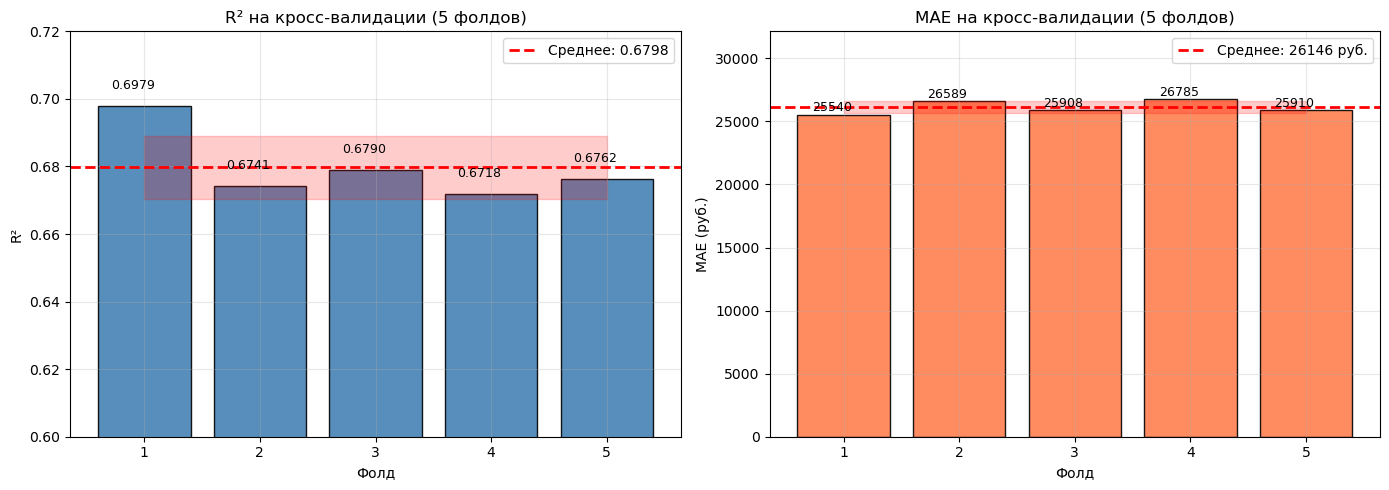

In [189]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(range(1, 6), r2_scores, color='steelblue', alpha=0.9, edgecolor='black')
axes[0].axhline(y=r2_scores.mean(), color='red', linestyle='--', linewidth=2, 
                label=f'Среднее: {r2_scores.mean():.4f}')
axes[0].fill_between(range(1, 6), r2_scores.mean() - r2_scores.std(), 
                     r2_scores.mean() + r2_scores.std(), alpha=0.2, color='red')
axes[0].set_xlabel('Фолд')
axes[0].set_ylabel('R²')
axes[0].set_title('R² на кросс-валидации (5 фолдов)')
axes[0].set_ylim(0.6, 0.72)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

for i, val in enumerate(r2_scores):
    axes[0].text(i + 0.9, val + 0.005, f'{val:.4f}', fontsize=9, ha='center')

axes[1].bar(range(1, 6), mae_scores, color='coral', alpha=0.9, edgecolor='black')
axes[1].axhline(y=mae_scores.mean(), color='red', linestyle='--', linewidth=2,
                label=f'Среднее: {mae_scores.mean():.0f} руб.')
axes[1].fill_between(range(1, 6), mae_scores.mean() - mae_scores.std(), 
                     mae_scores.mean() + mae_scores.std(), alpha=0.2, color='red')
axes[1].set_xlabel('Фолд')
axes[1].set_ylabel('MAE (руб.)')
axes[1].set_title('MAE на кросс-валидации (5 фолдов)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

y_max_mae = max(mae_scores)
axes[1].set_ylim(0, y_max_mae * 1.2)

for i, val in enumerate(mae_scores):
    axes[1].text(i + 0.9, val + 0.01 * y_max_mae, f'{val:.0f}', fontsize=9, ha='center')

plt.tight_layout()
plt.show()

### Результаты кросс-валидации

Модель LightGBM (tuned) стабильна: R² имеет небольшой разброс по фолдам, а MAE равна ~27,500 руб. Отклонением в пределах ±300 руб. - переобучение отсутствует, качество не зависит от состава обучающей подвыборки.

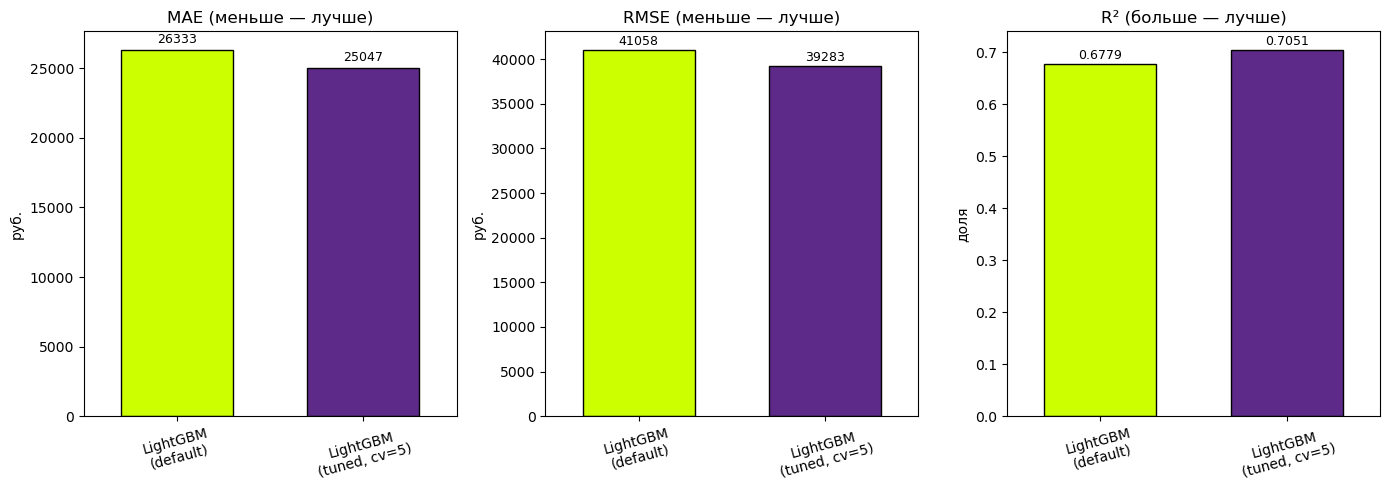

In [116]:
y_test_pred_base = lgb_model.predict(X_test) # получает метрики для базовой модели
mae_base = mean_absolute_error(y_test, y_test_pred_base)
rmse_base = np.sqrt(mean_squared_error(y_test, y_test_pred_base))
r2_base = r2_score(y_test, y_test_pred_base)

y_test_pred_tuned = best_lgb.predict(X_test) # получает метрики для тюнингованной модели
mae_tuned = mean_absolute_error(y_test, y_test_pred_tuned)
rmse_tuned = np.sqrt(mean_squared_error(y_test, y_test_pred_tuned))
r2_tuned = r2_score(y_test, y_test_pred_tuned)

models = ['LightGBM\n(default)', 'LightGBM\n(tuned, cv=5)']
mae = [mae_base, mae_tuned]
rmse = [rmse_base, rmse_tuned]
r2 = [r2_base, r2_tuned]

x = np.arange(len(models))
width = 0.6  # ширина столбцов

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
colors = ['#ccff00', '#5e2a8a']

bars1 = axes[0].bar(x, mae, width, color=colors, edgecolor='black')
axes[0].set_title('MAE (меньше — лучше)', fontsize=12)
axes[0].set_ylabel('руб.')
axes[0].set_xticks(x)
axes[0].set_xticklabels(models, rotation=15)
axes[0].set_xlim(-0.5, 1.5)  # сужаем диапазон, сближая столбцы
for bar, val in zip(bars1, mae):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 500, f'{val:.0f}', ha='center', fontsize=9)

bars2 = axes[1].bar(x, rmse, width, color=colors, edgecolor='black')
axes[1].set_title('RMSE (меньше — лучше)', fontsize=12)
axes[1].set_ylabel('руб.')
axes[1].set_xticks(x)
axes[1].set_xticklabels(models, rotation=15)
axes[1].set_xlim(-0.5, 1.5)
for bar, val in zip(bars2, rmse):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 500, f'{val:.0f}', ha='center', fontsize=9)

bars3 = axes[2].bar(x, r2, width, color=colors, edgecolor='black')
axes[2].set_title('R² (больше — лучше)', fontsize=12)
axes[2].set_ylabel('доля')
axes[2].set_xticks(x)
axes[2].set_xticklabels(models, rotation=15)
axes[2].set_xlim(-0.5, 1.5)
for bar, val in zip(bars3, r2):
    axes[2].text(bar.get_x() + bar.get_width()/2, val + 0.01, f'{val:.4f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

### Сравнение до и после подбора параметров

Тюнингованная LightGBM превосходит базовую по всем метрикам (MAE, RMSE, R²) - подбор гиперпараметров дал значимый прирост качества.

## 11. Оценка итоговой модели

Лучшая модель - LightGBM (tuned). Качество оценено на тестовой выборке (MAE, RMSE, R²), также приведен scatter-plot "факт vs прогноз".


In [26]:
y_test_pred = best_lgb.predict(X_test)

mae = mean_absolute_error(y_test, y_test_pred)
mse = mean_squared_error(y_test, y_test_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_test_pred)

print("Лучшая модель: LightGBM (tuned).")
print(f"""Итоговое качество на тестовой выборке:
   MAE = {mae:.0f} руб. Модель ошибается в среднем на +-{mae:.0f} руб.
   RMSE = {rmse:.0f}. Модель сильнее ошибается на крупных значениях (например, при предсказании зарплат топ-менеджеров).
   R² = {r2:.4f}. Модель объясняет {r2*100:.1f}% дисперсии зарплат.
""")

Лучшая модель: LightGBM (tuned).
Итоговое качество на тестовой выборке:
   MAE = 25047 руб. Модель ошибается в среднем на +-25047 руб.
   RMSE = 39283. Модель сильнее ошибается на крупных значениях (например, при предсказании зарплат топ-менеджеров).
   R² = 0.7051. Модель объясняет 70.5% дисперсии зарплат.



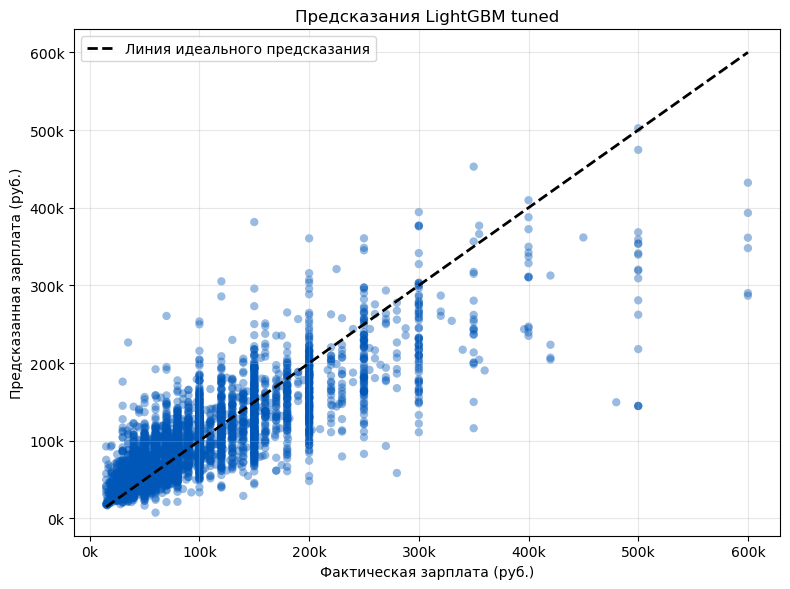

In [25]:
y_pred = best_lgb.predict(X_test)

fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(y_test, y_pred, alpha=0.4, color='#0057B8', edgecolors='none')
ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2, label='Линия идеального предсказания')
ax.set_xlabel('Фактическая зарплата (руб.)')
ax.set_ylabel('Предсказанная зарплата (руб.)')
ax.set_title('Предсказания LightGBM tuned', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)

def fmt(x, p):
    return f'{int(x/1000)}k'
ax.xaxis.set_major_formatter(plt.FuncFormatter(fmt))
ax.yaxis.set_major_formatter(plt.FuncFormatter(fmt))

plt.tight_layout()
plt.show()

### Итоговое качество

Модель LightGBM хорошо предсказывает зарплаты до ~200k руб. - точки на графике "факт/прогноз" следуют вдоль идеальной линии. Для высоких зарплат (>200k руб.) качество падает - это связано с недостатком примеров дорогих вакансий в данных и влиянием факторов, не попавших в признаки (срочность найма, конкретная компания, бонусы). Для массовых позиций точность достаточна для ориентировочной рыночной оценки.


## 12. Интерпретация модели

Важность признаков для финальной LightGBM (tuned) исследована через **Permutation Importance**. Данные численные значения не сравниваются с Random Forest (этап 6) напрямую, т.к. модели разной природы.


In [86]:
X_test_sample, y_test_sample = resample(
    X_test, y_test, 
    n_samples=min(5000, X_test.shape[0]), # выборка 5000 строк для экономии времени и памяти
    random_state=42
)

# Преобразует разреженную матрицу в плотный массив
X_test_dense = X_test_sample.toarray() if hasattr(X_test_sample, 'toarray') else X_test_sample

perm_importance = permutation_importance(
    best_lgb, X_test_dense, y_test_sample,
    n_repeats=5,
    scoring='neg_mean_absolute_error',
    random_state=42,
    n_jobs=-1
)

In [100]:
feature_names = [f'cat_{i}' for i in range(5)] + [f'skill_{i}' for i in range(100)] + [f'desc_{i}' for i in range(200)]

importance_df_lgb = pd.DataFrame({
    'feature': feature_names[:len(perm_importance.importances_mean)],
    'importance': perm_importance.importances_mean,
    'std': perm_importance.importances_std
}).sort_values('importance', ascending=False)


print("Топ-20 важных признаков:")
print(importance_df_lgb[['feature', 'importance']].head(20))


Топ-20 важных признаков:
      feature   importance
1       cat_1  9570.343795
0       cat_0  8683.659219
2       cat_2  2620.559207
213  desc_108   932.916077
210  desc_105   681.658868
261  desc_156   653.270998
266  desc_161   474.056948
147   desc_42   468.113100
110    desc_5   428.796152
4       cat_4   394.286441
3       cat_3   344.250789
183   desc_78   331.314890
115   desc_10   244.828254
177   desc_72   197.438925
120   desc_15   181.304267
11    skill_6   177.878745
149   desc_44   156.473494
225  desc_120   145.158043
7     skill_2   142.105721
222  desc_117   137.427697


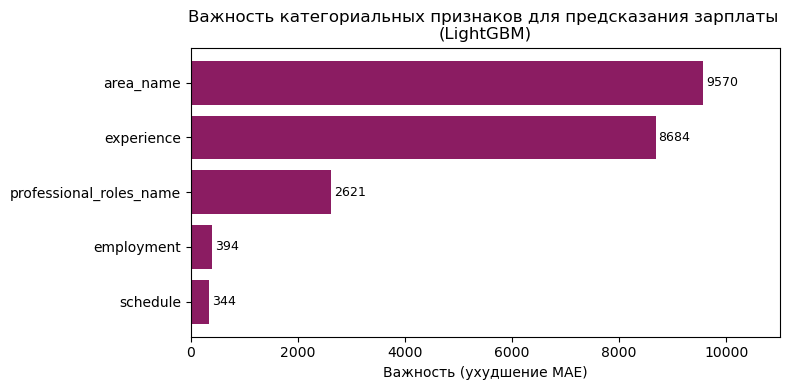

In [119]:
cat_feature_names_with_idx = [
    ('cat_0', 'experience'),
    ('cat_1', 'area_name'),
    ('cat_2', 'professional_roles_name'),
    ('cat_3', 'schedule'),
    ('cat_4', 'employment')
]

# Только категориальные признаки
cat_importance_df_lgb = importance_df_lgb[importance_df_lgb['feature'].isin(['cat_0', 'cat_1', 'cat_2', 'cat_3', 'cat_4'])].copy()
cat_importance_df_lgb['feature_name'] = cat_importance_df_lgb['feature'].map(dict(cat_feature_names_with_idx))
cat_importance_df_lgb = cat_importance_df_lgb.sort_values('importance', ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(cat_importance_df_lgb['feature_name'], cat_importance_df_lgb['importance'], color='#8B1C62')
ax.set_xlabel('Важность (ухудшение MAE)')
ax.set_title('Важность категориальных признаков для предсказания зарплаты \n(LightGBM)', fontsize=12)
ax.set_xlim(0, cat_importance_df_lgb['importance'].max() * 1.15)

for bar, val in zip(bars, cat_importance_df_lgb['importance']):
    ax.text(val + 50, bar.get_y() + bar.get_height()/2, f'{val:.0f}', va='center', fontsize=9)

ax.invert_yaxis()
plt.tight_layout()
plt.show()


### Значимость категориальных признаков

- Город и опыт - ключевые факторы
- Роль - средняя значимость
- Занятость и график влияют слабо

В LightGBM значимость employment выше, чем в Random Forest (этап 6) - модель лучше улавливает эффект типа занятости.


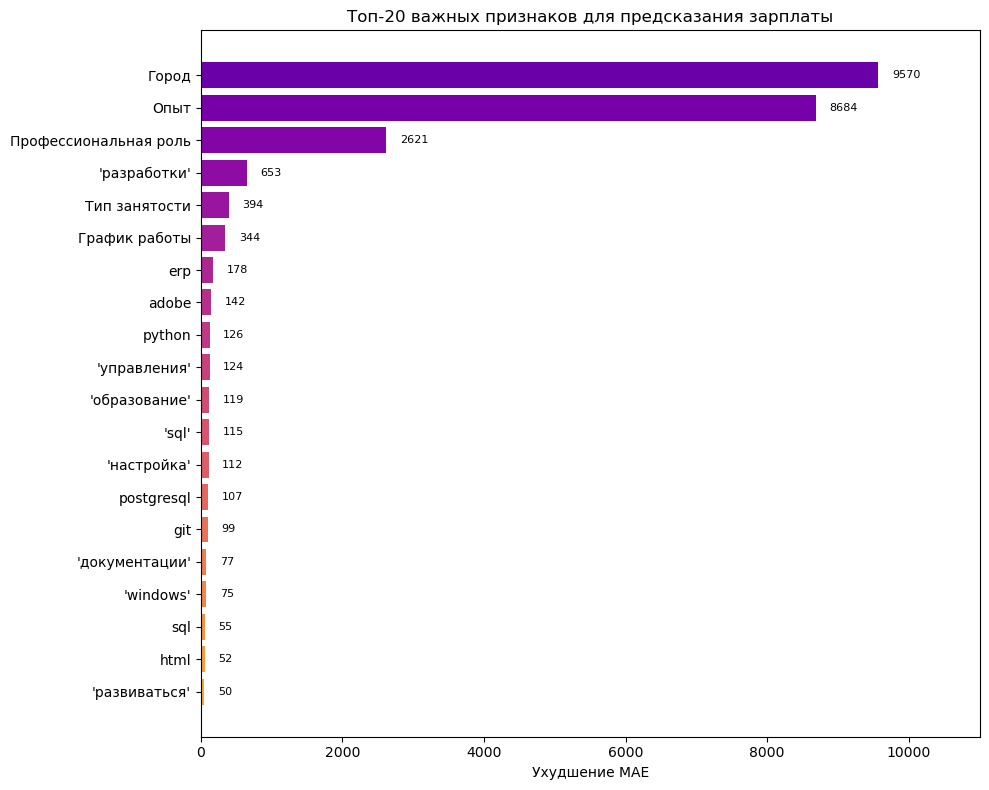

In [192]:
top = importance_df_lgb.head(80).copy() 
# Намеренно выбрано больше 20 из-за последующего удаления признаков стоп-фильтром

cat_mapping = {
    'cat_0': 'Опыт',
    'cat_1': 'Город',
    'cat_2': 'Профессиональная роль',
    'cat_3': 'График работы',
    'cat_4': 'Тип занятости'
}

# Расшифровка skill_ и desc_
skill_words = tfidf_skills.get_feature_names_out() if 'tfidf_skills' in dir() else [f'навык_{i}' for i in range(100)]
desc_words = tfidf_desc.get_feature_names_out() if 'tfidf_desc' in dir() else [f'слово_{i}' for i in range(200)]

# Стоп-слова для фильтрации
stop_words = {'опыт', 'обязанности', 'дмс', 'коллектив', 'команды', 'компании', 'компания', 'процессов', 'проектами', 'проектов', 'работа', 'strong', 'li', 'до', 'по', 'и', 'в', 'на', 'с', 'к', 'у', 'за', 'не', 'что', 'лет', 'для', 'от', 'из', 'без', 'более', 'менее', 'решений', 'решения', 'разработка', 'управление', 'уровень', 'участие', 'умение', 'бизнес', 'работы', 'работать', 'информации', 'знание', 'программного', 'дня', 'команде', 'клиентов', 'задач', 'навыки', 'предстоит', 'сервисов', 'сфере'}

def decode_feature(feat):
    if feat in cat_mapping:
        return cat_mapping[feat]
    elif feat.startswith('skill_'):
        idx = int(feat.split('_')[1])
        word = skill_words[idx] if idx < len(skill_words) else feat
        if word in stop_words or len(word) < 3:
            return None
        return f"{word}"
    elif feat.startswith('desc_'):
        idx = int(feat.split('_')[1])
        word = desc_words[idx] if idx < len(desc_words) else feat
        if word in stop_words or len(word) < 3:
            return None
        return f"'{word}'"
    else:
        return feat

top['feature_decoded'] = top['feature'].apply(decode_feature)

top = top[top['feature_decoded'].notna()] 
top = top.head(20)

fig, ax = plt.subplots(figsize=(10, 8))
colors = plt.cm.plasma(np.linspace(0.2, 0.8, len(top)))
bars = ax.barh(top['feature_decoded'], top['importance'], color=colors)
ax.set_xlabel('Важность (ухудшение MAE)')
ax.set_title('Топ-20 важных признаков для предсказания зарплаты', fontsize=12)
ax.invert_yaxis()

x_max = top['importance'].max()
ax.set_xlim(0, x_max * 1.15)

for bar, val in zip(bars, top['importance']):
    ax.text(val + x_max * 0.02, bar.get_y() + bar.get_height()/2, 
            f'{val:.0f}', va='center', fontsize=8)

plt.tight_layout()
plt.show()

### Топ важных признаков

1. Категориальные признаки:
- **Город** - главный фактор: разрыв между Москвой и регионами в 2-3 раза.
- **Опыт** - зарплата растёт с повышением требований.
- **Роль** - разные специальности оплачиваются по-разному.

2. **Навыки:** python, sql, postgresql, git, windows, erp, adobe - прямо коррелируют с зарплатой.

3. **Слова из описаний (в кавычках):** 'разработки', 'управления', 'образование', 'настройка', 'документации', 'развиваться' - маркеры сложности и ответственности.

SQL можно увидеть и в навыках, и в тексте описаний - его востребованность дважды подтверждена.


## Выводы и практическая значимость

### Бизнес-применение
Модель может использоваться на разных сторонах рынка. Вот конкретные сценарии:
- HR-отделы - автоматическая валидация зарплатных вилок: завышенные/заниженные ожидания видны сразу.
- Соискатели - объективный рыночный ориентир: навыки python, SQL, PostgreSQL как точки роста зарплаты. ERP и Adobe - маркеры высоких зарплат в специфических доменах (корпоративные системы, дизайн/графика).
- Платформы по поиску работы (агрегаторы) - рекомендации вакансий с учётом рыночного диапазона.
- Региональные работодатели - модель подсвечивает разрыв с Москвой, помогая формировать конкурентное предложение.

### Ограничения
- Permutation Importance показывает, насколько признак важен конкретно для этой модели LightGBM, а не объективную причинно-следственную связь в реальном мире. Смена модели или данных может изменить картину важности признаков.
- Нет данных о размере компании, отрасли, соцпакете, срочности найма.
- Данные за один месяц — нет сезонности и трендов.

### Дальнейшие улучшения
Для повышения качества предсказаний можно: 
- Добавить признаки компании (размер, рейтинг, отрасль).
- Продвинутые методы работы с текстом: эмбеддинги (Word2Vec, RuBERT) вместо TF-IDF.
- Собрать данные за год+ для учёта сезонности.
- Предсказывать полную вилку зарплаты (salary_from и salary_to), а не только нижнюю границу.
- Ансамбли или калибровка для улучшения точности на высоких зарплатах.
